# Statistical Significance Testing

To determine whether the observed performance differences between BiLSTM and BERT are statistically significant, statistical hypothesis testing is performed on the F1-scores obtained from ten independent runs.

The Shapiro–Wilk test is first applied to the paired differences between the models to assess normality. If the normality assumption is satisfied (p > 0.05), a paired t-test is conducted. Otherwise, the non-parametric Wilcoxon Signed-Rank Test is used.

A significance level of α = 0.05 is adopted throughout the analysis.

In [1]:
import pandas as pd

from scipy.stats import (
    shapiro,
    ttest_rel,
    wilcoxon
)

## Load Experimental Results

The results obtained from ten independent runs of BiLSTM and BERT are loaded for each dataset.

In [15]:
BASE_PATH = r"C:\Users\dell\Sarcasm_detection_socialmedia_NLP\Result\10run Result"

datasets = {

    "SemEval": (
        rf"{BASE_PATH}\LSTM\SemEval_LSTM_10runs.csv",
        rf"{BASE_PATH}\BERT\SemEval_BERT_10runs.csv"
    ),

    "Headlines": (
        rf"{BASE_PATH}\LSTM\Headlines_LSTM_10runs.csv",
        rf"{BASE_PATH}\BERT\Headlines_BERT_10runs.csv"
    ),

    "Reddit_No_Context": (
        rf"{BASE_PATH}\LSTM\Reddit_No_Context_LSTM_10runs.csv",
        rf"{BASE_PATH}\BERT\Reddit_No_Context_BERT_10runs.csv"
    ),

    "Reddit_With_Context": (
        rf"{BASE_PATH}\LSTM\Reddit_With_Context_LSTM_10runs.csv",
        rf"{BASE_PATH}\BERT\Reddit_With_Context_BERT_10runs.csv"
    )
}

## Normality Testing

The Shapiro–Wilk test is applied to the paired differences between BERT and BiLSTM F1-scores.

Hypotheses:

- H0: The paired differences are normally distributed.
- H1: The paired differences are not normally distributed.

If p > 0.05, the normality assumption is satisfied.

In [17]:
normality_results = []

for dataset_name, (lstm_file, bert_file) in datasets.items():

    lstm = pd.read_csv(lstm_file)
    bert = pd.read_csv(bert_file)

    differences = bert["F1"] - lstm["F1"]

    stat, p = shapiro(differences)

    normality_results.append({

        "Dataset": dataset_name,

        "Shapiro Statistic": stat,

        "p-value": p,

        "Normal?": "Yes" if p > 0.05 else "No"
    })

normality_df = pd.DataFrame(
    normality_results
)

normality_df

,Dataset,Shapiro Statistic,p-value,Normal?
0,SemEval,0.883233,0.142106,Yes
1,Headlines,0.921473,0.369408,Yes
2,Reddit_No_Context,0.922616,0.379288,Yes
3,Reddit_With_Context,0.859743,0.075778,Yes


## Welch's Independent t-Test

After verifying that the normality assumption is satisfied using the Shapiro–Wilk test, Welch's independent two-sample t-test is applied to compare the F1-scores obtained by the BiLSTM and BERT models.

Welch's t-test is selected because the experiments were conducted using independent runs for each model and the random seeds were not paired across runs. Unlike the standard Student's t-test, Welch's t-test does not assume equal variances between the two groups and is therefore more appropriate for comparing the performance distributions of the two models.

The hypotheses are defined as follows:

- **Null Hypothesis ($H_0$):** There is no statistically significant difference between the mean F1-scores of BiLSTM and BERT.
- **Alternative Hypothesis ($H_1$):** There is a statistically significant difference between the mean F1-scores of BiLSTM and BERT.

A significance level of $\alpha = 0.05$ is adopted. If the obtained p-value is less than 0.05, the null hypothesis is rejected.

In [20]:
from scipy.stats import ttest_ind
import pandas as pd

welch_results = []

for dataset_name, (lstm_file, bert_file) in datasets.items():

    lstm = pd.read_csv(lstm_file)
    bert = pd.read_csv(bert_file)

    statistic, p_value = ttest_ind(
        lstm["F1"],
        bert["F1"],
        equal_var=False
    )

    welch_results.append({
        "Dataset": dataset_name,
        "t-statistic": statistic,
        "p-value": p_value,
        "Significant?":
            "Yes" if p_value < 0.05 else "No"
    })

welch_df = pd.DataFrame(welch_results)

welch_df

,Dataset,t-statistic,p-value,Significant?
0,SemEval,-4.072364,2.787666e-03,Yes
1,Headlines,-40.598703,1.551767e-12,Yes
2,Reddit_No_Context,-13.296166,1.587316e-07,Yes
3,Reddit_With_Context,-7.764732,2.480847e-05,Yes


## Effect Size Analysis

While statistical significance testing determines whether a performance difference exists, effect size analysis quantifies the magnitude of that difference.

Cohen's d is computed to measure the practical significance of the performance gap between BiLSTM and BERT. Larger values indicate stronger differences between the models.

The following interpretation guidelines are used:

- Small effect: d = 0.2
- Medium effect: d = 0.5
- Large effect: d = 0.8
- Very large effect: d > 1.2

In [25]:
import pandas as pd
import numpy as np

effect_sizes = []

for dataset_name, (lstm_file, bert_file) in datasets.items():

    lstm = pd.read_csv(lstm_file)
    bert = pd.read_csv(bert_file)

    x1 = lstm["F1"]
    x2 = bert["F1"]

    n1 = len(x1)
    n2 = len(x2)

    s1 = np.std(x1, ddof=1)
    s2 = np.std(x2, ddof=1)

    pooled_std = np.sqrt(
        ((n1 - 1) * s1**2 +
         (n2 - 1) * s2**2)
        / (n1 + n2 - 2)
    )

    cohen_d = (
        x2.mean() - x1.mean()
    ) / pooled_std

    if abs(cohen_d) < 0.2:
        interpretation = "Negligible"
    elif abs(cohen_d) < 0.5:
        interpretation = "Small"
    elif abs(cohen_d) < 0.8:
        interpretation = "Medium"
    elif abs(cohen_d) < 1.2:
        interpretation = "Large"
    else:
        interpretation = "Very Large"

    effect_sizes.append({

        "Dataset": dataset_name,

        "Cohen's d":
            round(cohen_d, 4),

        "Interpretation":
            interpretation
    })

effect_df = pd.DataFrame(effect_sizes)

effect_df

,Dataset,Cohen's d,Interpretation
0,SemEval,1.8212,Very Large
1,Headlines,18.1563,Very Large
2,Reddit_No_Context,5.9462,Very Large
3,Reddit_With_Context,3.4725,Very Large


## Interpretation of Effect Sizes

Cohen's d measures the magnitude of the performance difference between BiLSTM and BERT.

Large positive values indicate that BERT substantially outperformed BiLSTM. Combined with the statistically significant p-values obtained from Welch's t-test, the effect size analysis provides evidence that the observed improvements are not only statistically significant but also practically meaningful.

Therefore, both statistical significance testing and effect size analysis support the superiority of BERT for sarcasm and irony detection across the evaluated datasets.

## Summary Statistics

To evaluate the average performance and stability of the models across repeated experiments, the mean and standard deviation of the F1-scores obtained from ten independent runs are computed.

The mean F1-score provides an estimate of the overall predictive performance, while the standard deviation measures the variability of the model across repeated runs. Lower standard deviation values indicate more stable and consistent model behaviour.

In [24]:
summary_results = []

for dataset_name, (lstm_file, bert_file) in datasets.items():

    lstm = pd.read_csv(lstm_file)
    bert = pd.read_csv(bert_file)

    summary_results.append({

        "Dataset": dataset_name,

        "LSTM Mean F1":
            round(lstm["F1"].mean(), 4),

        "LSTM Std F1":
            round(lstm["F1"].std(), 4),

        "BERT Mean F1":
            round(bert["F1"].mean(), 4),

        "BERT Std F1":
            round(bert["F1"].std(), 4)
    })

summary_df = pd.DataFrame(summary_results)

summary_df

,Dataset,LSTM Mean F1,LSTM Std F1,BERT Mean F1,BERT Std F1
0,SemEval,0.5722,0.2956,0.9529,0.0039
1,Headlines,0.8558,0.0056,0.9300,0.0014
2,Reddit_No_Context,0.6462,0.0178,0.7225,0.0034
3,Reddit_With_Context,0.5821,0.0563,0.7211,0.0059


## Interpretation of Summary Statistics

The summary statistics provide an overview of the performance and stability of both models across ten independent runs.

Across all datasets, BERT achieved higher mean F1-scores than BiLSTM, indicating superior predictive performance. In addition, BERT consistently exhibited lower standard deviation values, suggesting more stable and reliable behaviour across repeated executions.

These observations indicate that transformer-based architectures are more effective and robust than recurrent neural network architectures for sarcasm and irony detection. However, statistical significance testing is required to determine whether these observed differences are statistically meaningful rather than resulting from random variation.

# Final Conclusion

This statistical analysis compared the performance of BiLSTM and BERT using F1-scores obtained from ten independent runs on each dataset.

The summary statistics showed that BERT consistently achieved higher mean F1-scores and lower standard deviations than BiLSTM across all datasets, indicating both superior performance and greater stability.

The Shapiro–Wilk normality test confirmed that the performance distributions satisfied the normality assumption. Consequently, Welch's independent t-test was employed to compare the mean F1-scores of the two models.

For all datasets, the obtained p-values were below the significance threshold of 0.05. Therefore, the null hypothesis of no performance difference was rejected. These results demonstrate that BERT significantly outperformed BiLSTM on all evaluated datasets.

Overall, the findings indicate that transformer-based language models are more effective than recurrent neural network architectures for sarcasm and irony detection in the considered datasets.

## Mean F1-score Comparison

The following figure compares the average F1-scores achieved by BiLSTM and BERT across ten independent runs on each dataset. Higher F1-scores indicate better sarcasm and irony detection performance.

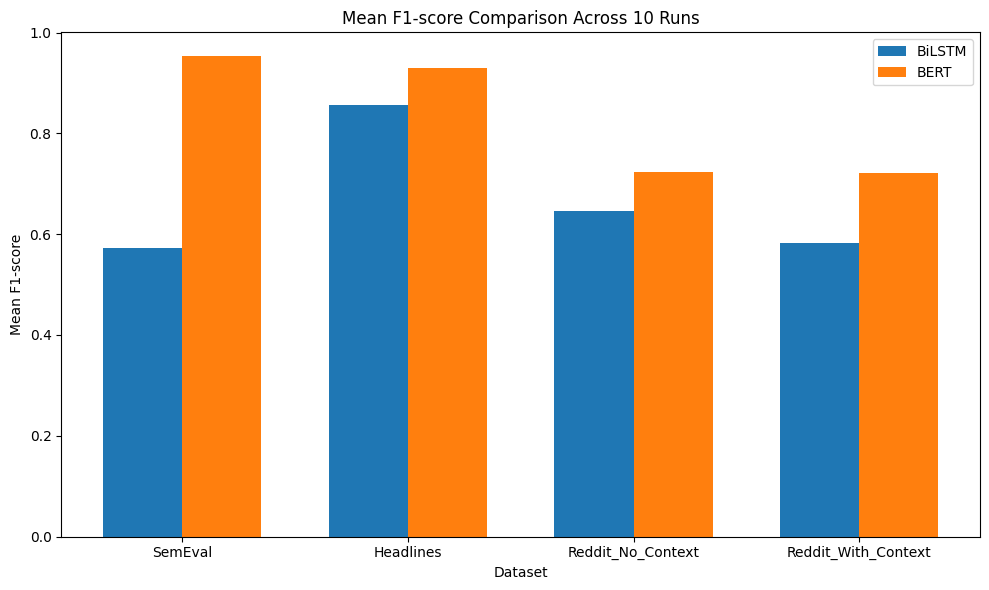

In [27]:
import numpy as np
import matplotlib.pyplot as plt

datasets_names = summary_df["Dataset"]

lstm_means = summary_df["LSTM Mean F1"]
bert_means = summary_df["BERT Mean F1"]

x = np.arange(len(datasets_names))
width = 0.35

plt.figure(figsize=(10,6))

plt.bar(
    x - width/2,
    lstm_means,
    width,
    label="BiLSTM"
)

plt.bar(
    x + width/2,
    bert_means,
    width,
    label="BERT"
)

plt.xticks(x, datasets_names)

plt.ylabel("Mean F1-score")

plt.xlabel("Dataset")

plt.title(
    "Mean F1-score Comparison Across 10 Runs"
)

plt.legend()

plt.tight_layout()

plt.show()

The figure shows that BERT consistently achieved higher mean F1-scores than BiLSTM on all datasets. The largest improvement was observed on the SemEval dataset, while consistent gains were also obtained on Headlines, Reddit No Context, and Reddit With Context datasets.

## Distribution of F1-scores Across Independent Runs

The boxplot illustrates the distribution of F1-scores obtained from ten independent runs for each model and dataset. It provides insights into performance variability, median performance, and potential outliers.

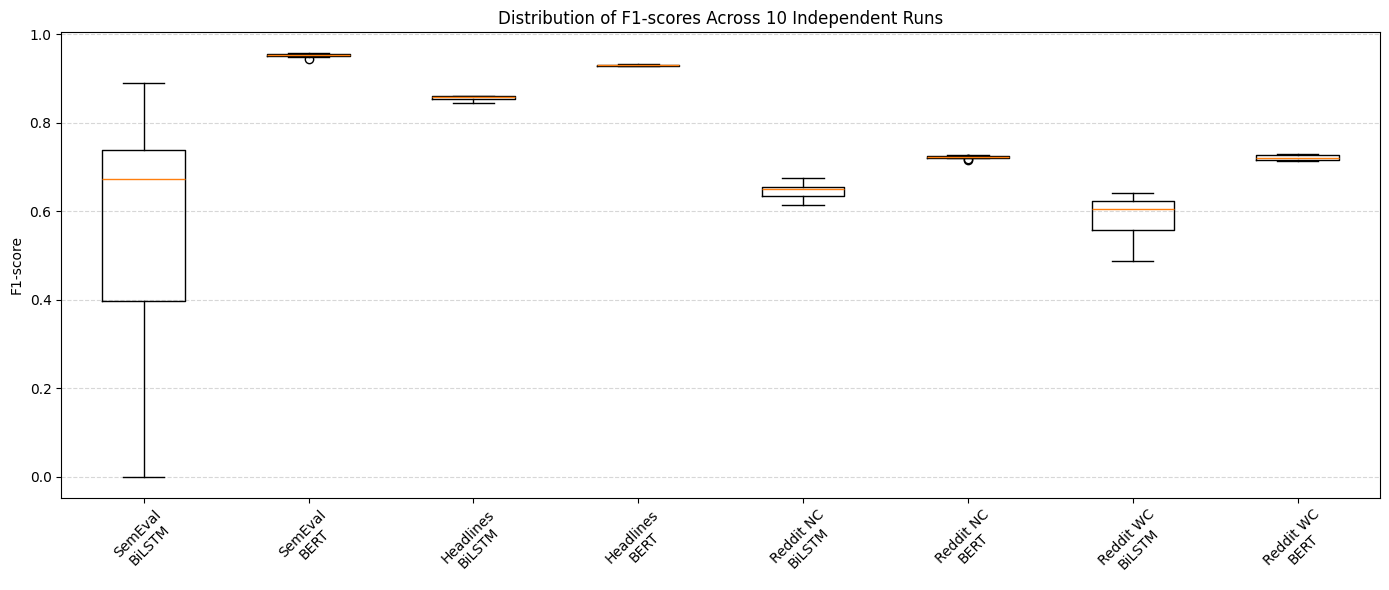

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

plot_data = []

for dataset_name, (lstm_file, bert_file) in datasets.items():

    lstm = pd.read_csv(lstm_file)
    bert = pd.read_csv(bert_file)

    plot_data.append(lstm["F1"])
    plot_data.append(bert["F1"])

labels = [
    "SemEval\nBiLSTM",
    "SemEval\nBERT",
    "Headlines\nBiLSTM",
    "Headlines\nBERT",
    "Reddit NC\nBiLSTM",
    "Reddit NC\nBERT",
    "Reddit WC\nBiLSTM",
    "Reddit WC\nBERT"
]

plt.figure(figsize=(14,6))

plt.boxplot(plot_data)

plt.xticks(
    range(1, len(labels)+1),
    labels,
    rotation=45
)

plt.ylabel("F1-score")

plt.title(
    "Distribution of F1-scores Across 10 Independent Runs"
)

plt.tight_layout()
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

The boxplots illustrate the distribution of F1-scores obtained from ten independent runs for each model and dataset. BERT consistently achieved higher median F1-scores and lower variability than BiLSTM across all datasets. The most pronounced difference was observed on the SemEval dataset, where BiLSTM exhibited substantial performance fluctuations, while BERT maintained highly stable performance across runs. These observations are consistent with the summary statistics and further support the superiority and robustness of BERT for sarcasm and irony detection.